In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def show_mean(dim : int, filename : str) -> None:
    """
    Muestra la media de hitting time en función del tamaño del espacio.
    
    Parámetros:
    - dim (int): Dimensión del espacio.
    - filename (str): Nombre del archivo CSV.
    """

    df = pd.read_csv(f"../data/{filename}")
    df = df[df["Dimension"] == f"{dim}D"]
    return df

In [12]:
def get_data(dimension, filename):

    df = pd.read_csv(f"../data/{filename}")
    df = df[df["Dimension"] == f"{dimension}D"]
    df.columns = df.columns.str.strip()
    
    return list(df.itertuples(index = False, name = None))

In [13]:
def plot_hitting_time(data):
    """
    Genera un gráfico del Hitting Time, su dispersión (STD) y el valor máximo
    en función del Size dentro de una misma dimensión.

    Parámetros:
    - data (list of tuples): Lista de tuplas con (Dimension, Size, Mean Hitting, STD, Max).
    """

    # Extraer datos por separado
    sizes = np.array([row[1] for row in data])  # Segundo elemento: Size
    mean_hitting = np.array([row[2] for row in data])  # Tercer elemento: Mean Hitting
    std_hitting = np.array([row[3] for row in data])  # Cuarto elemento: STD
    max_hitting = np.array([row[4] for row in data])  # Quinto elemento: Max

    # Obtener la dimensión
    dimension_label = f"{data[0][0]}"  # Extrae la primera dimensión de los datos

    # Calcular la multiplicidad (Max / Mean)
    multiplicidad = max_hitting / mean_hitting

    # Crear la figura con fondo uniforme
    fig, ax = plt.subplots(figsize = (22, 12))
    fig.patch.set_facecolor("#f8f8f8")  # Fondo general del gráfico
    ax.set_facecolor("#f0f0f0")  # Fondo del área de la gráfica

    # Gráfico del Hitting Time con barras de error (STD)
    ax.errorbar(sizes, mean_hitting, yerr = std_hitting, fmt = 'o-', color = 'blue', linewidth = 2, markersize = 8, label = "Hitting Time (±STD)")

    # Gráfico del valor máximo de hitting time
    ax.fill_between(sizes, mean_hitting - std_hitting, mean_hitting + std_hitting, color = 'blue', alpha = 0.2)
    ax.plot(sizes, max_hitting, linestyle = "--", marker = "s", color = "red", linewidth = 2, markersize = 8, label = "Max")

    # Agregar etiquetas de los valores en cada punto
    for x, y1, y2, m in zip(sizes, mean_hitting, max_hitting, multiplicidad):
        ax.text(x, y1 * 1.1, f"{y1:.2f}", fontsize = 12, ha = 'center', va = 'bottom',
                bbox=dict(facecolor = 'white', edgecolor = 'black', boxstyle = 'round,pad=0.3'))
        ax.text(x, y2 * 1.1, f"{y2:.2f}", fontsize = 12, ha = 'center', va = 'bottom', color = 'red', bbox = dict(facecolor = 'white', edgecolor = 'red', boxstyle = 'round,pad=0.3'))
        ax.text(x, (y1 + y2) / 2, f"x{m:.2f}", fontsize = 12, ha = 'center', va = 'center', color = 'green', bbox = dict(facecolor = 'white', edgecolor = 'green', boxstyle = 'round,pad=0.3'))

    # Ajustar escala sin notación científica en los ejes
    ax.set_xscale("log")  # Escala logarítmica en X
    ax.set_yscale("log")  # Escala logarítmica en Y
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))  
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}")) 

    # Configuración del gráfico
    ax.set_xlabel("Size", fontsize = 18, fontweight = "bold")
    ax.set_ylabel("Hitting Time", fontsize = 18, fontweight = "bold")
    ax.set_title(dimension_label, fontsize = 22, fontweight = "bold")  # Solo la dimensión + "D"
    ax.legend(fontsize = 16)
    ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.7, alpha = 0.7) 
    # Mostrar gráfico
    plt.savefig(f'../data/graphics/hitting_{dimension_label}')
    plt.show()
    


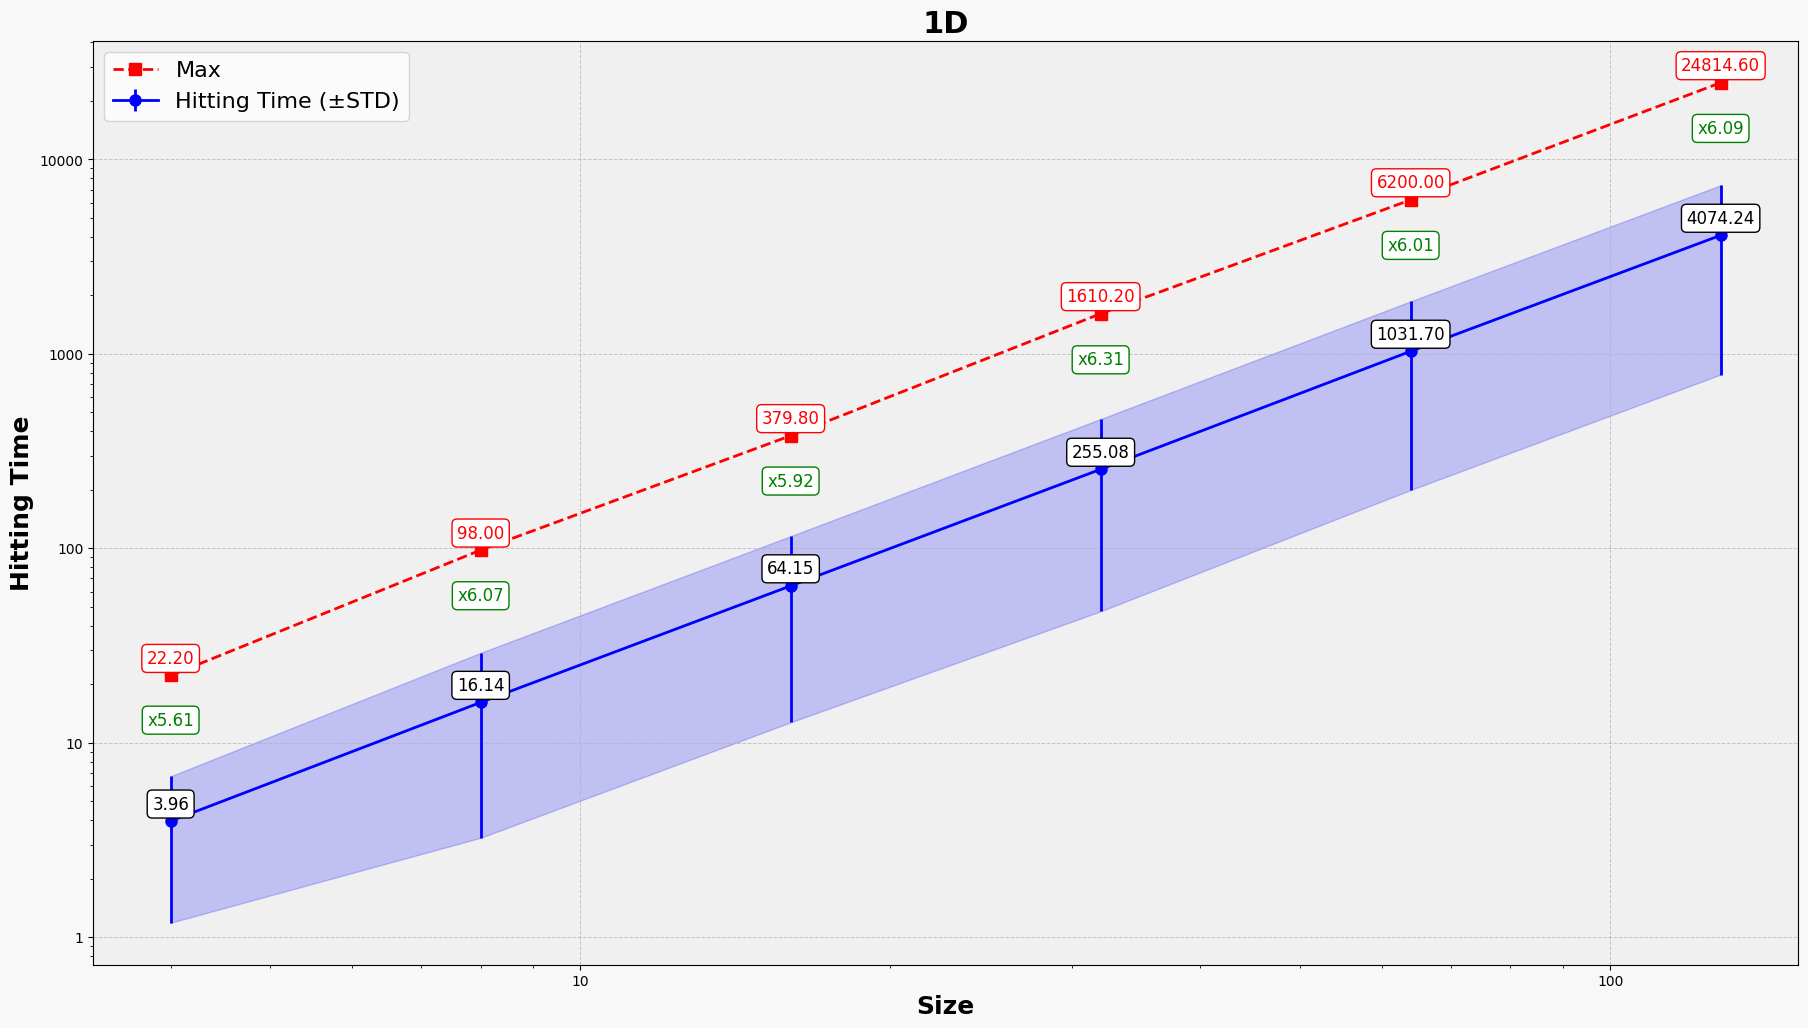

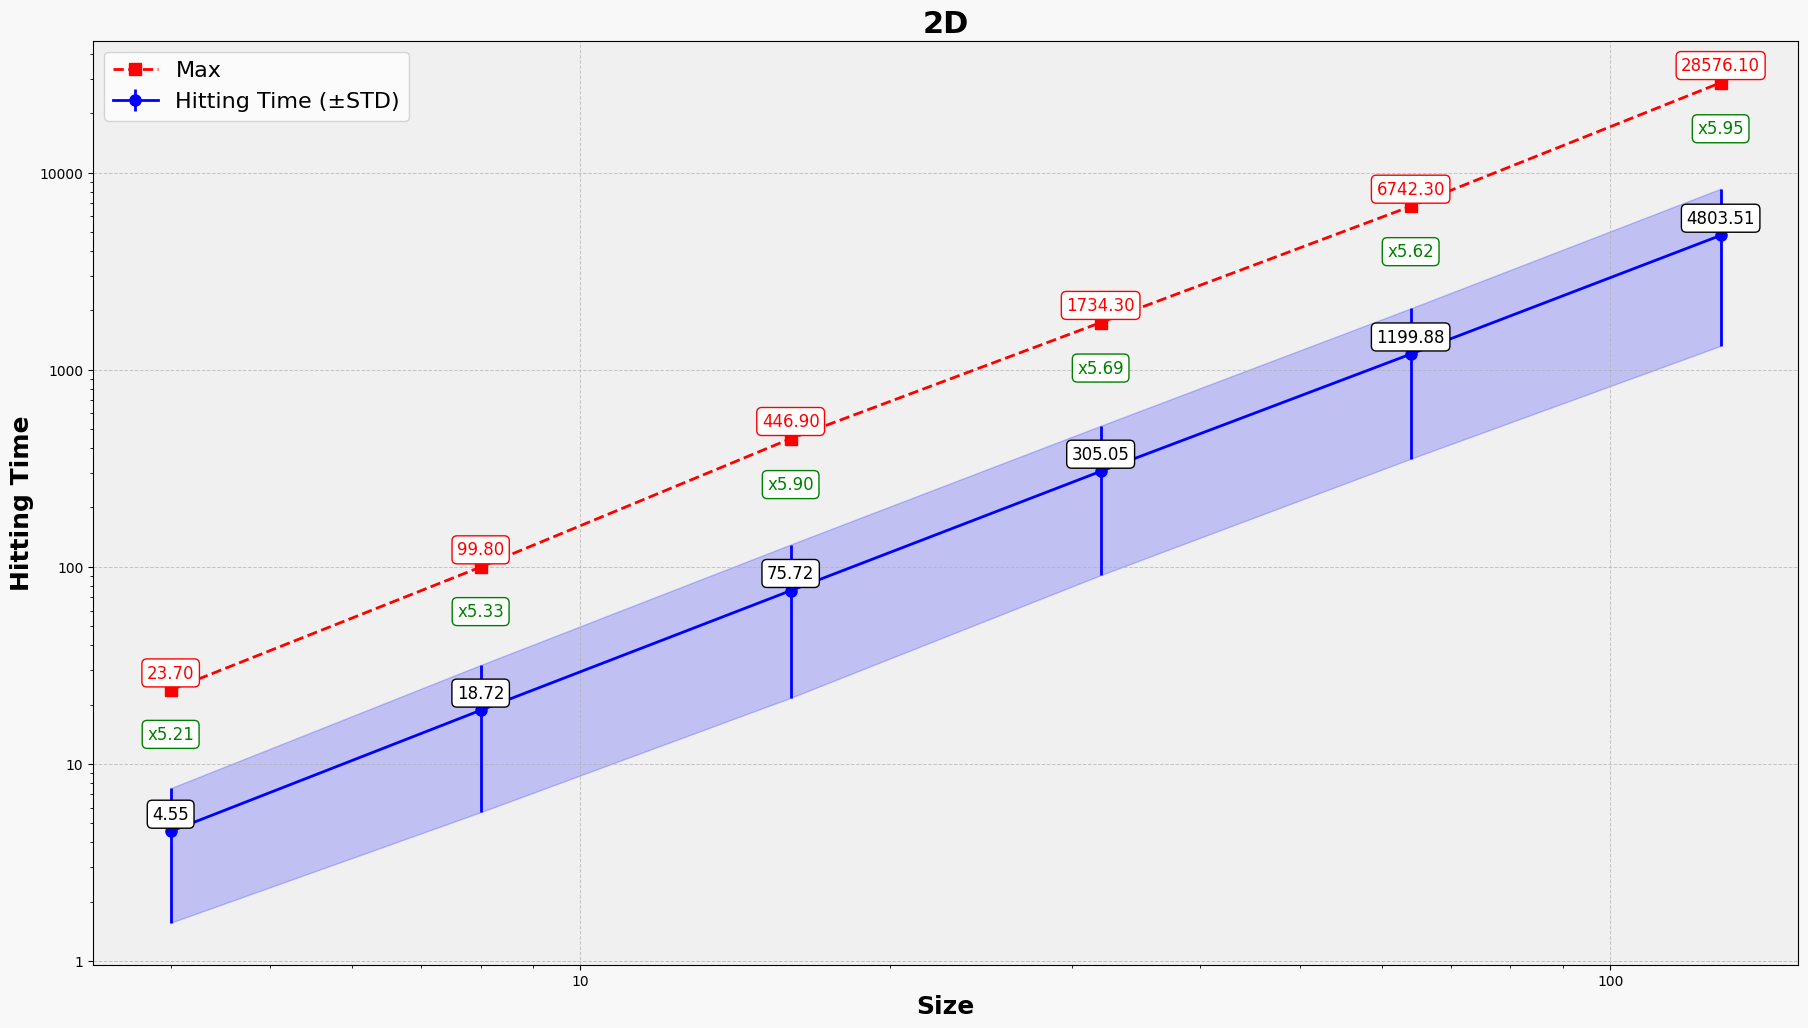

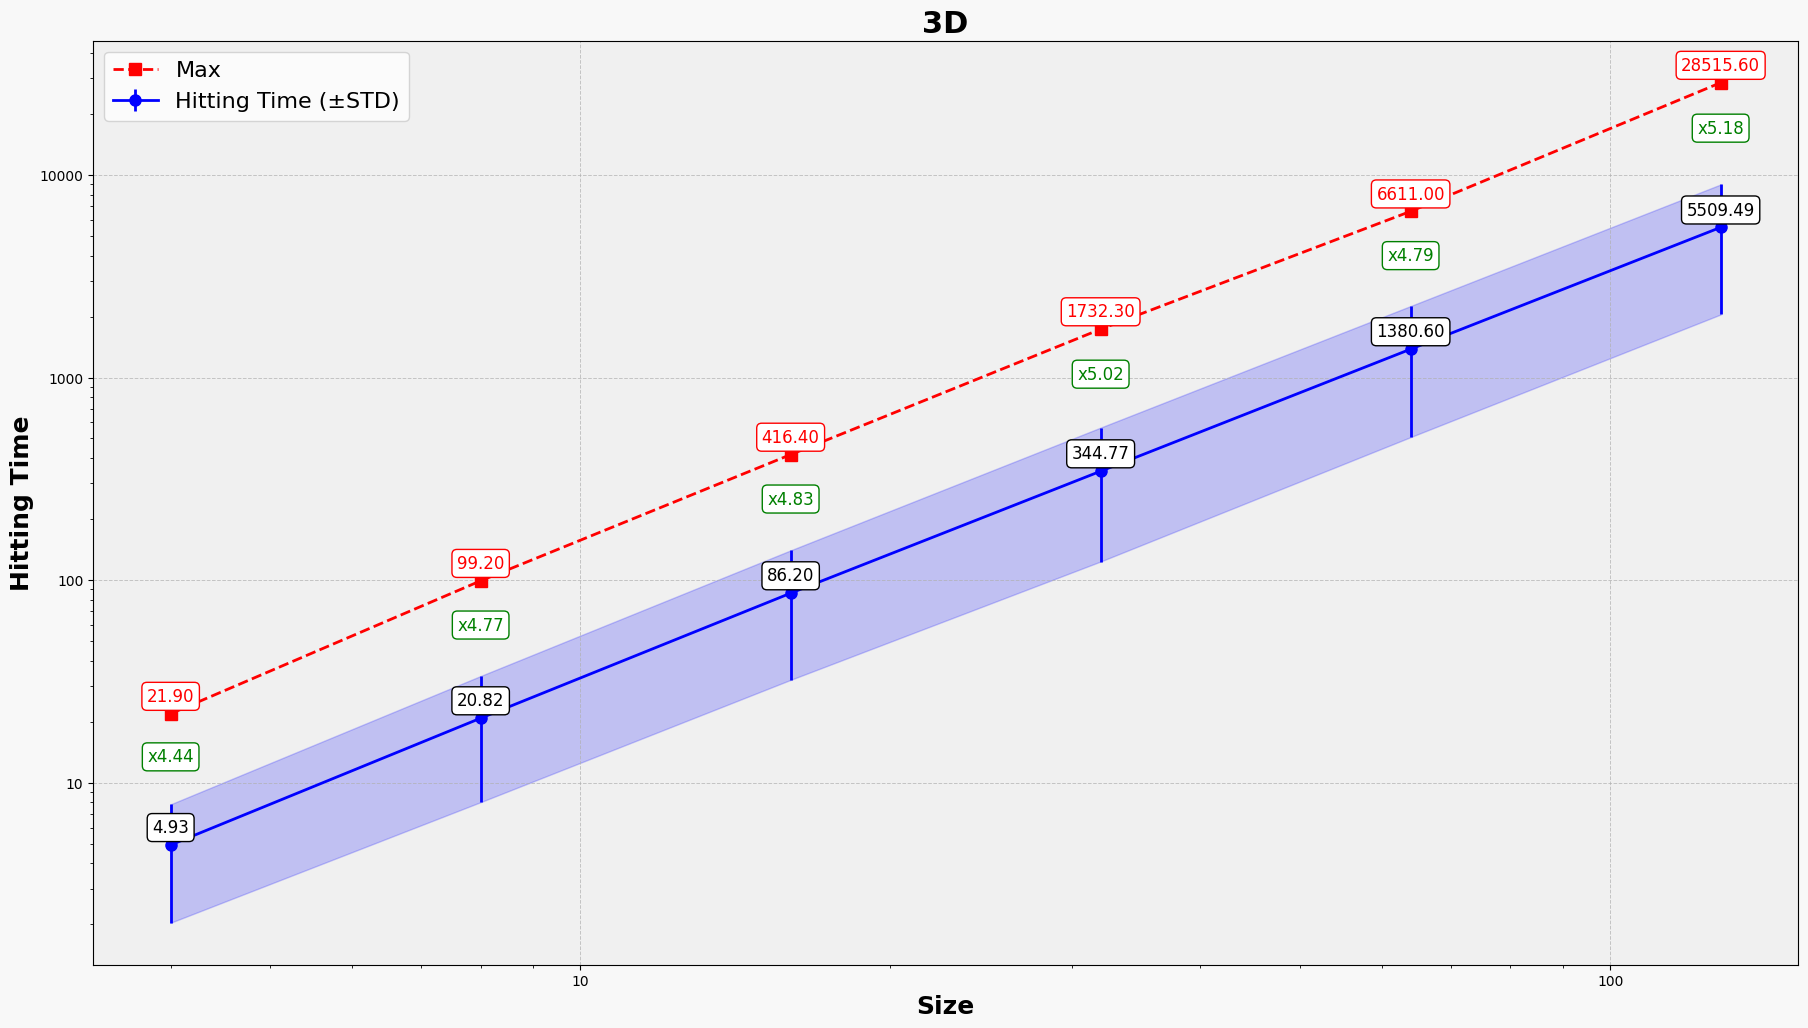

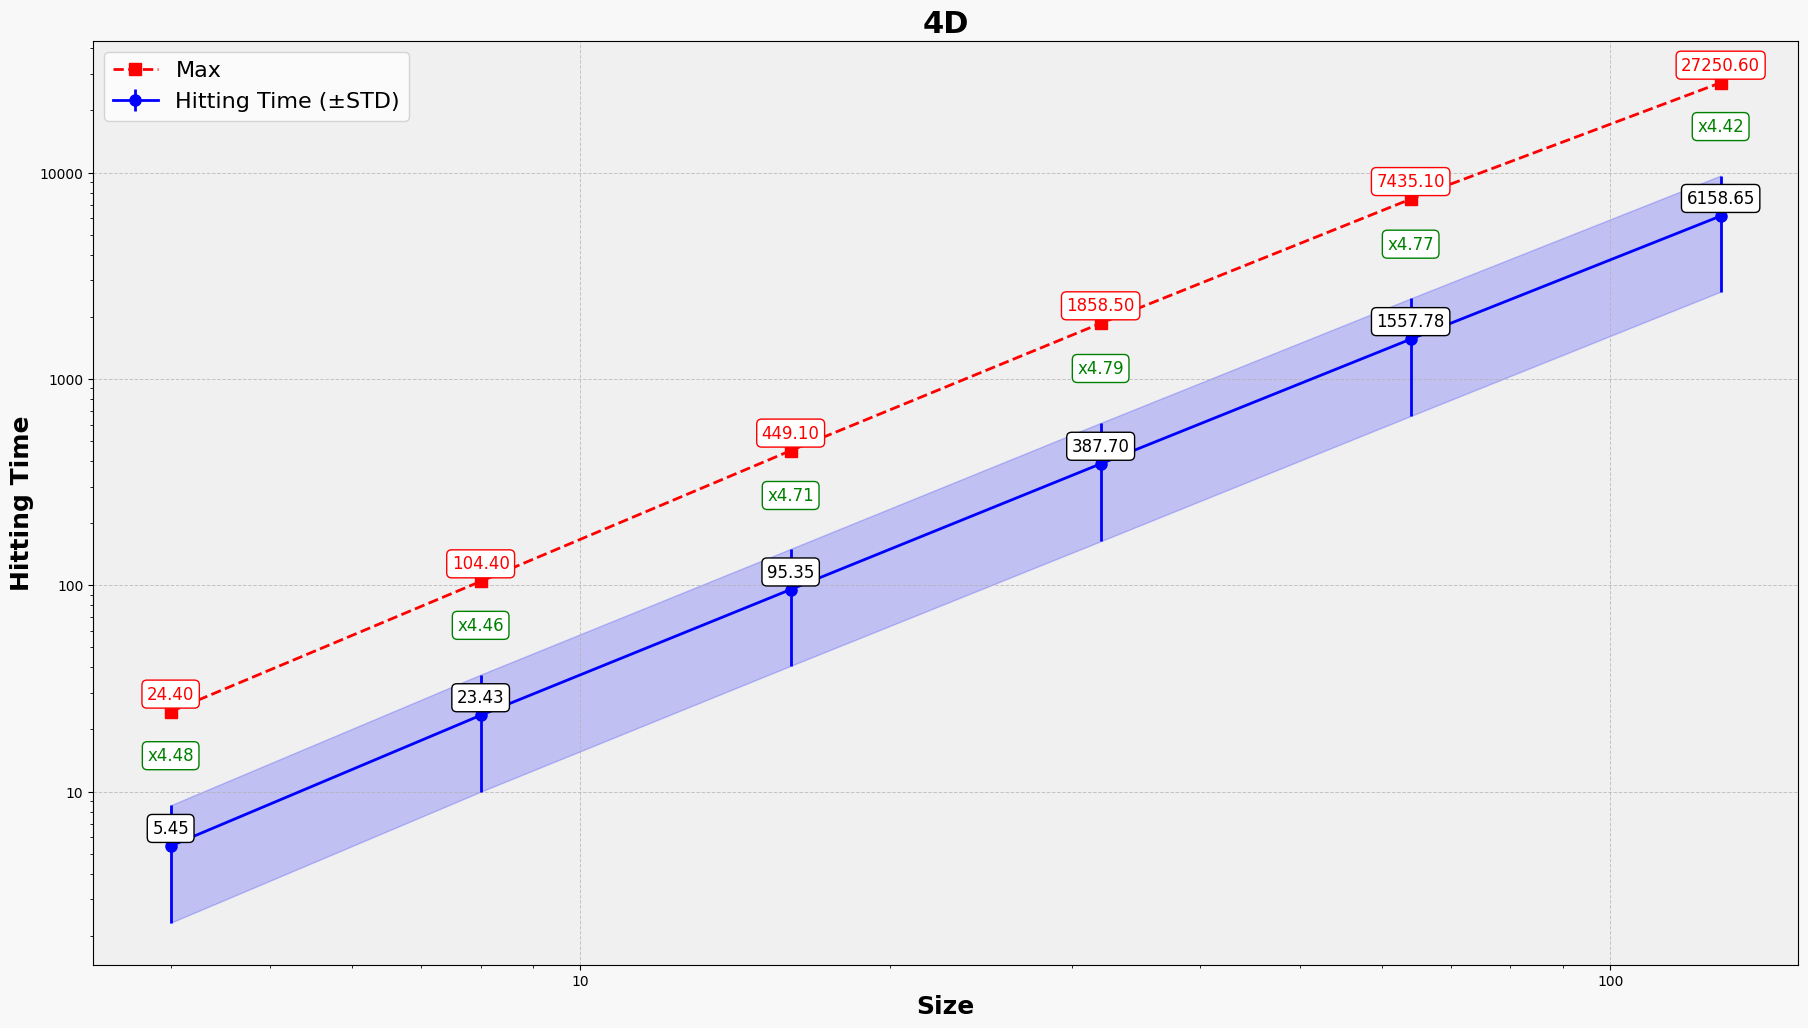

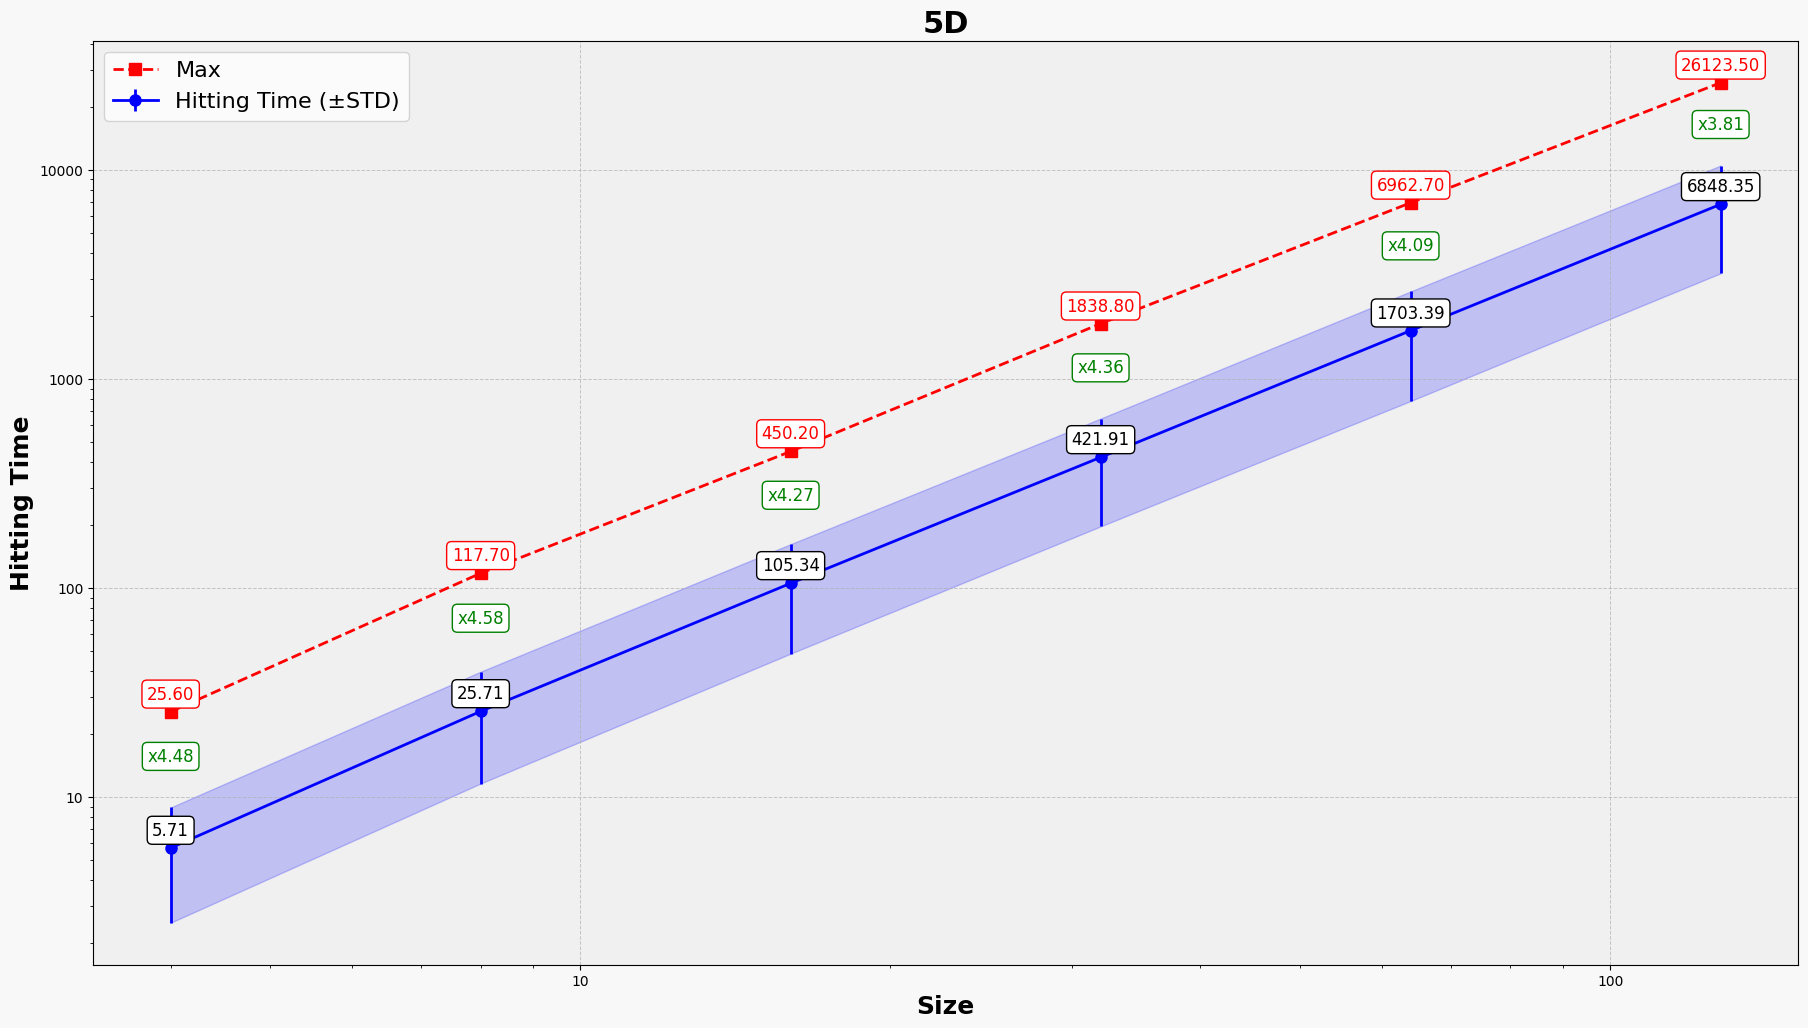

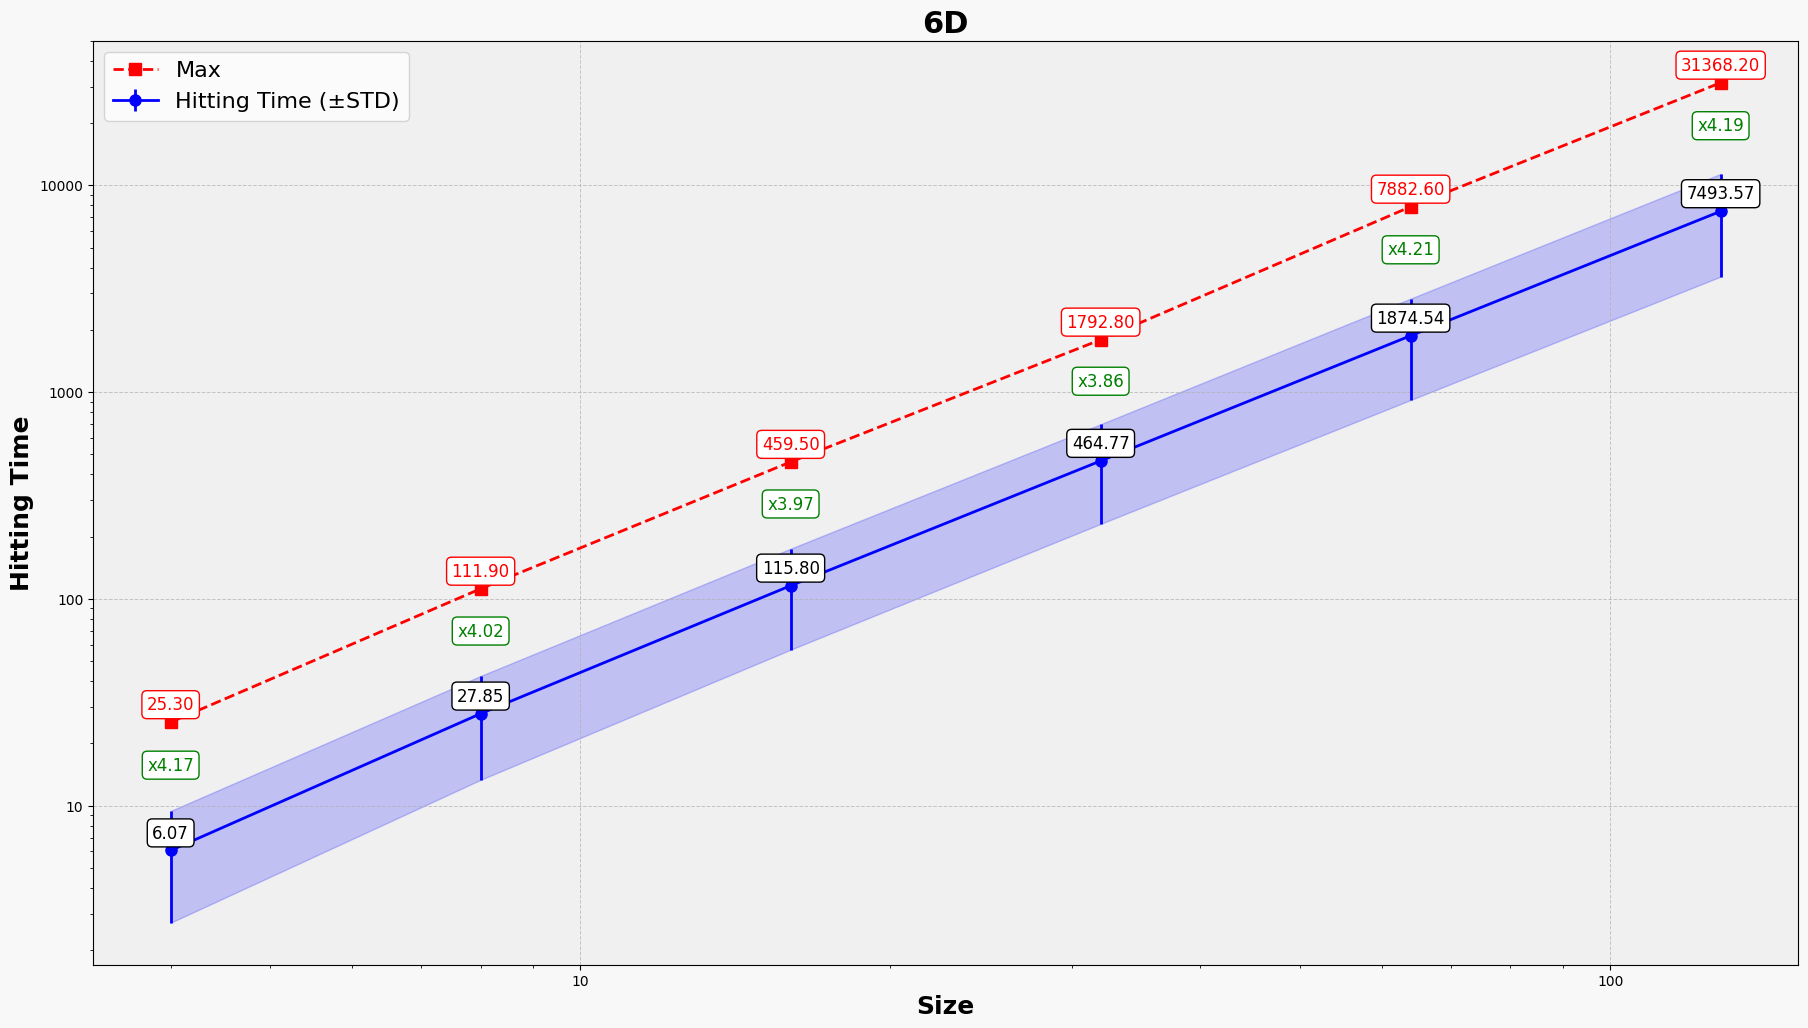

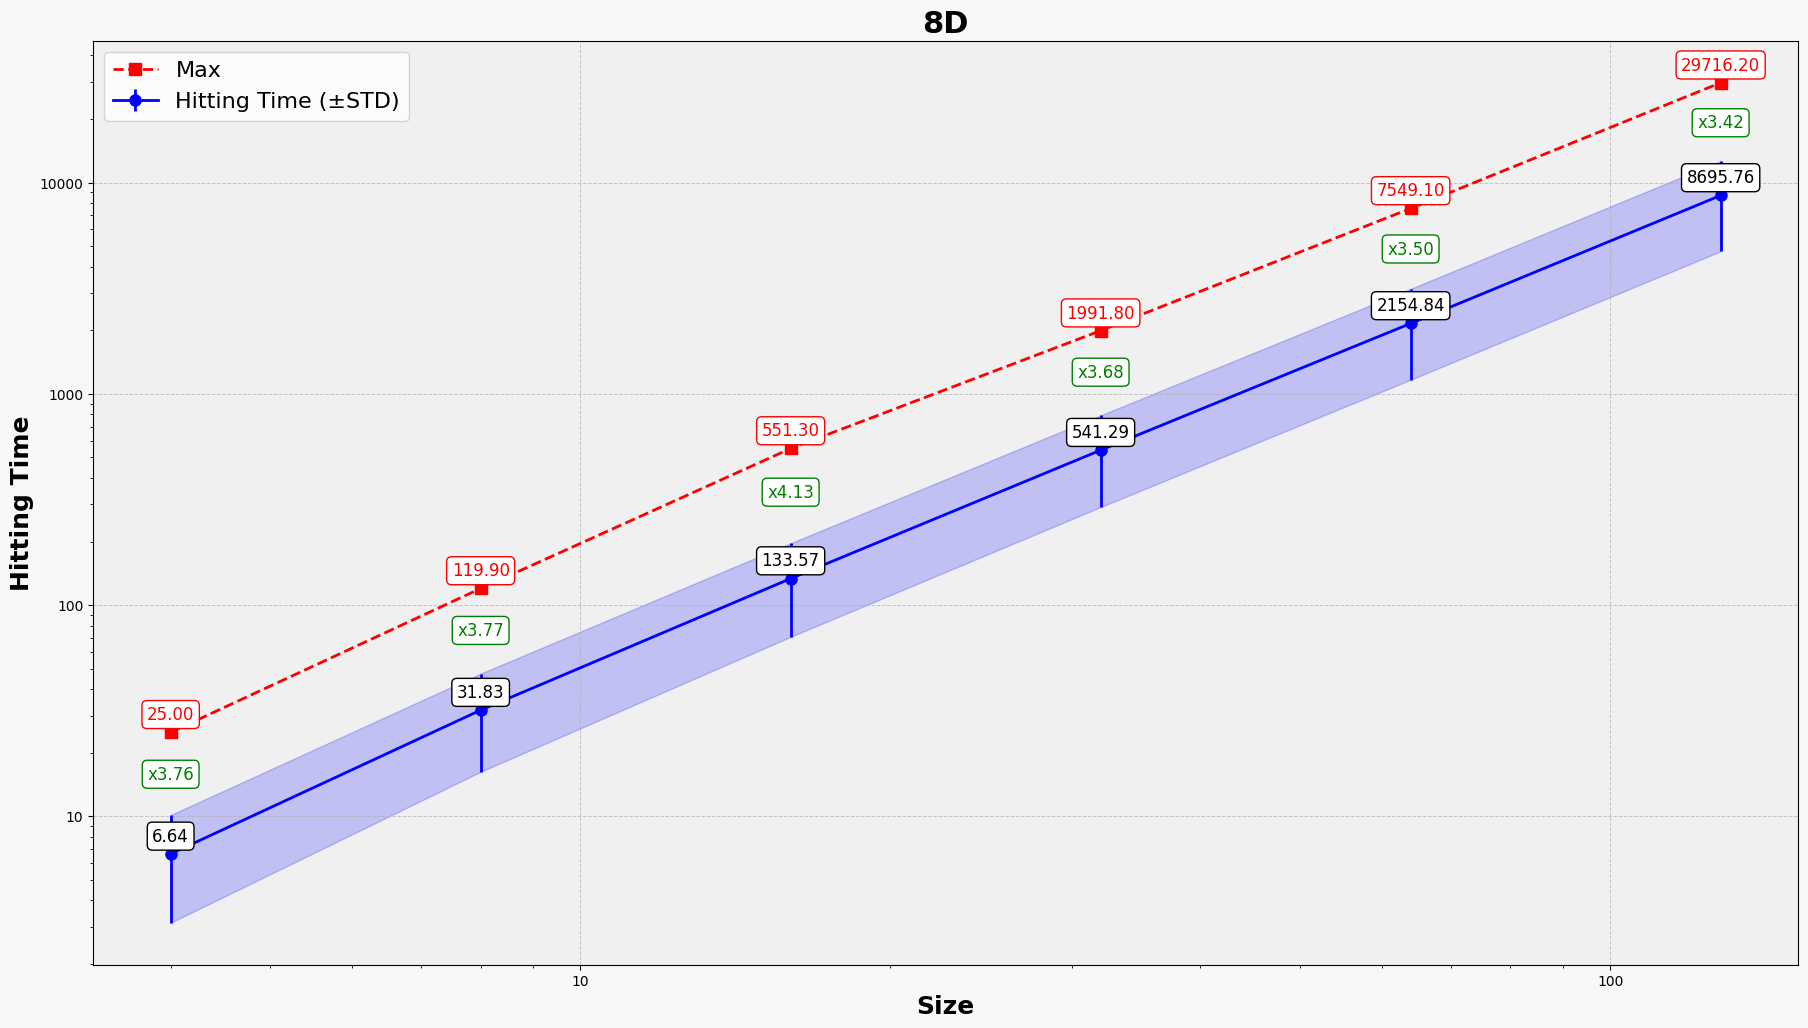

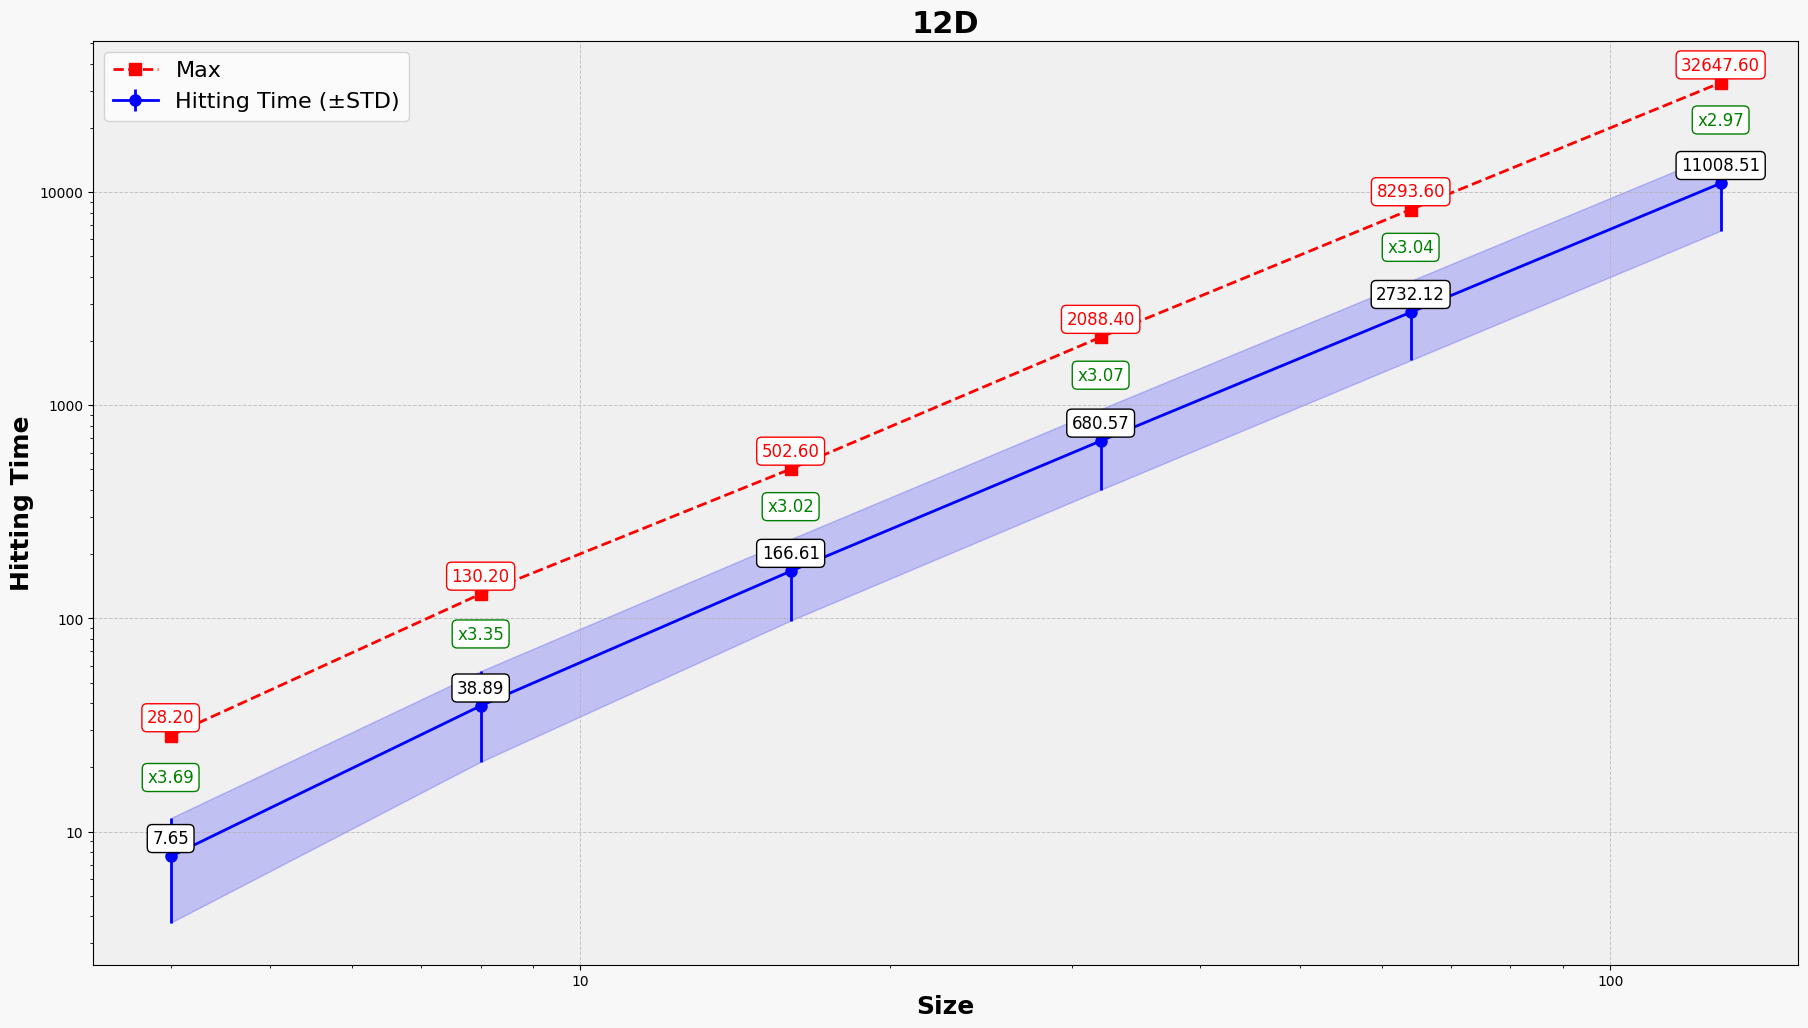

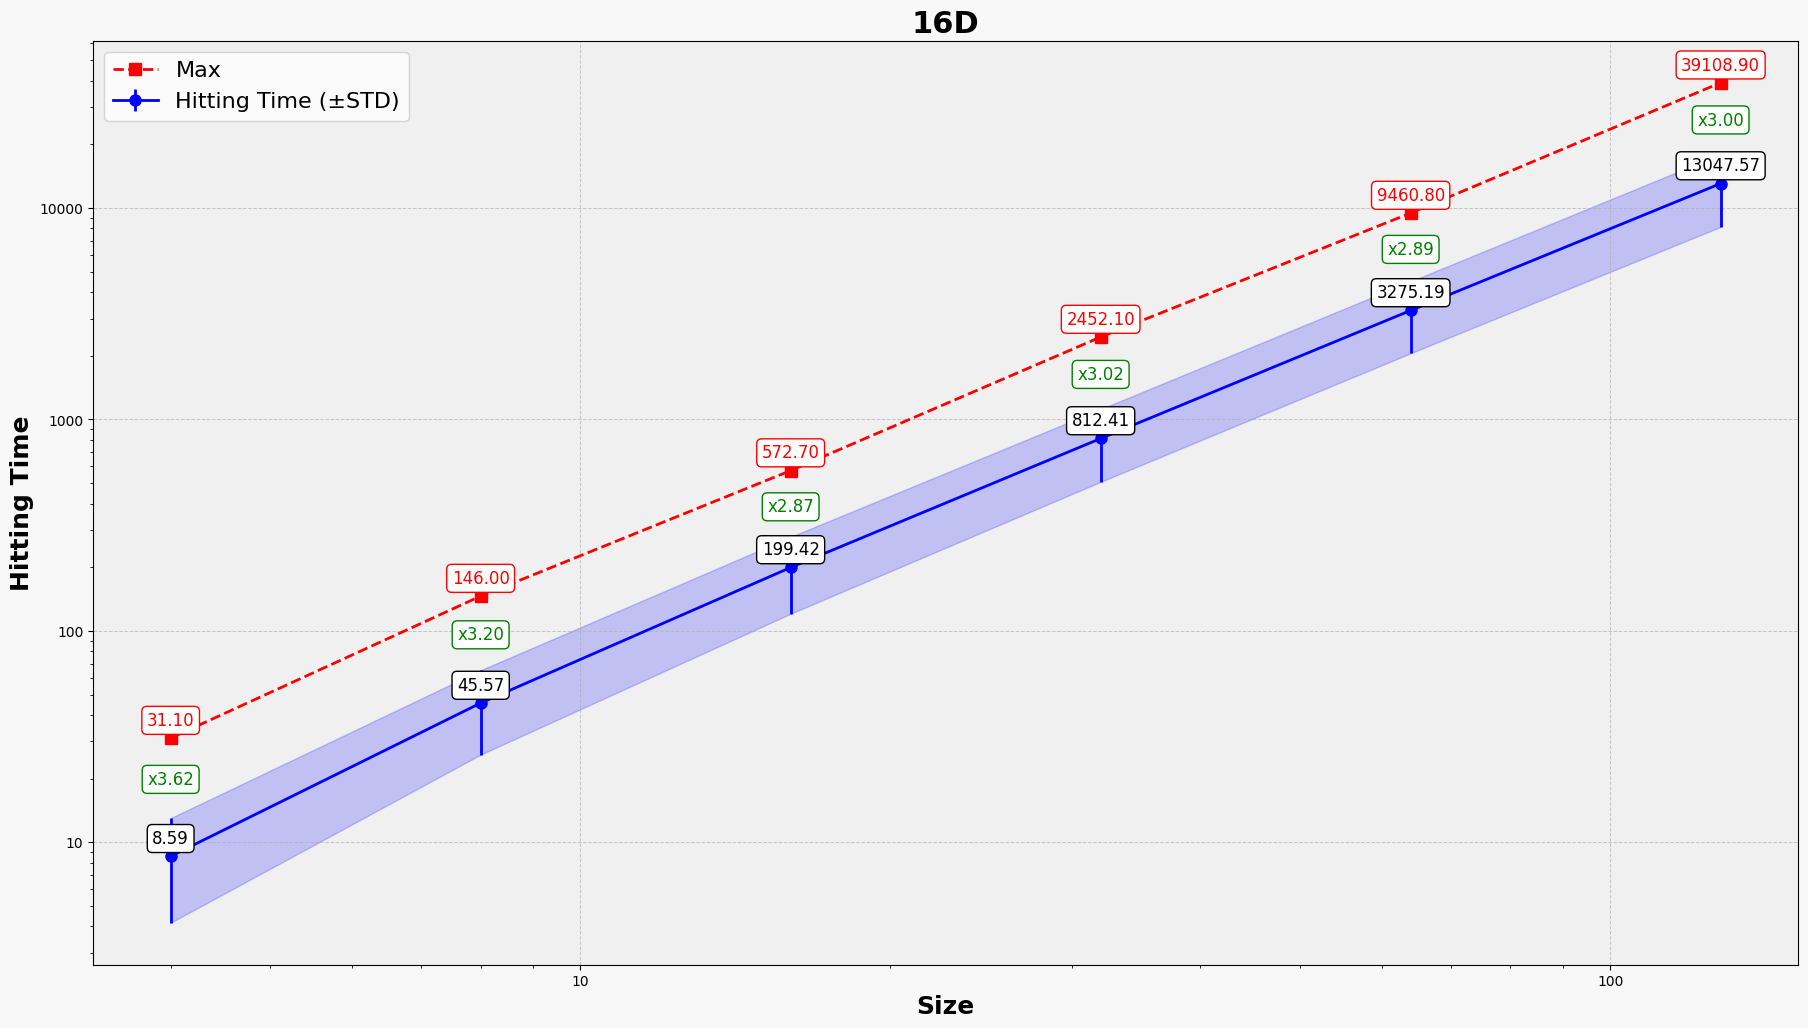

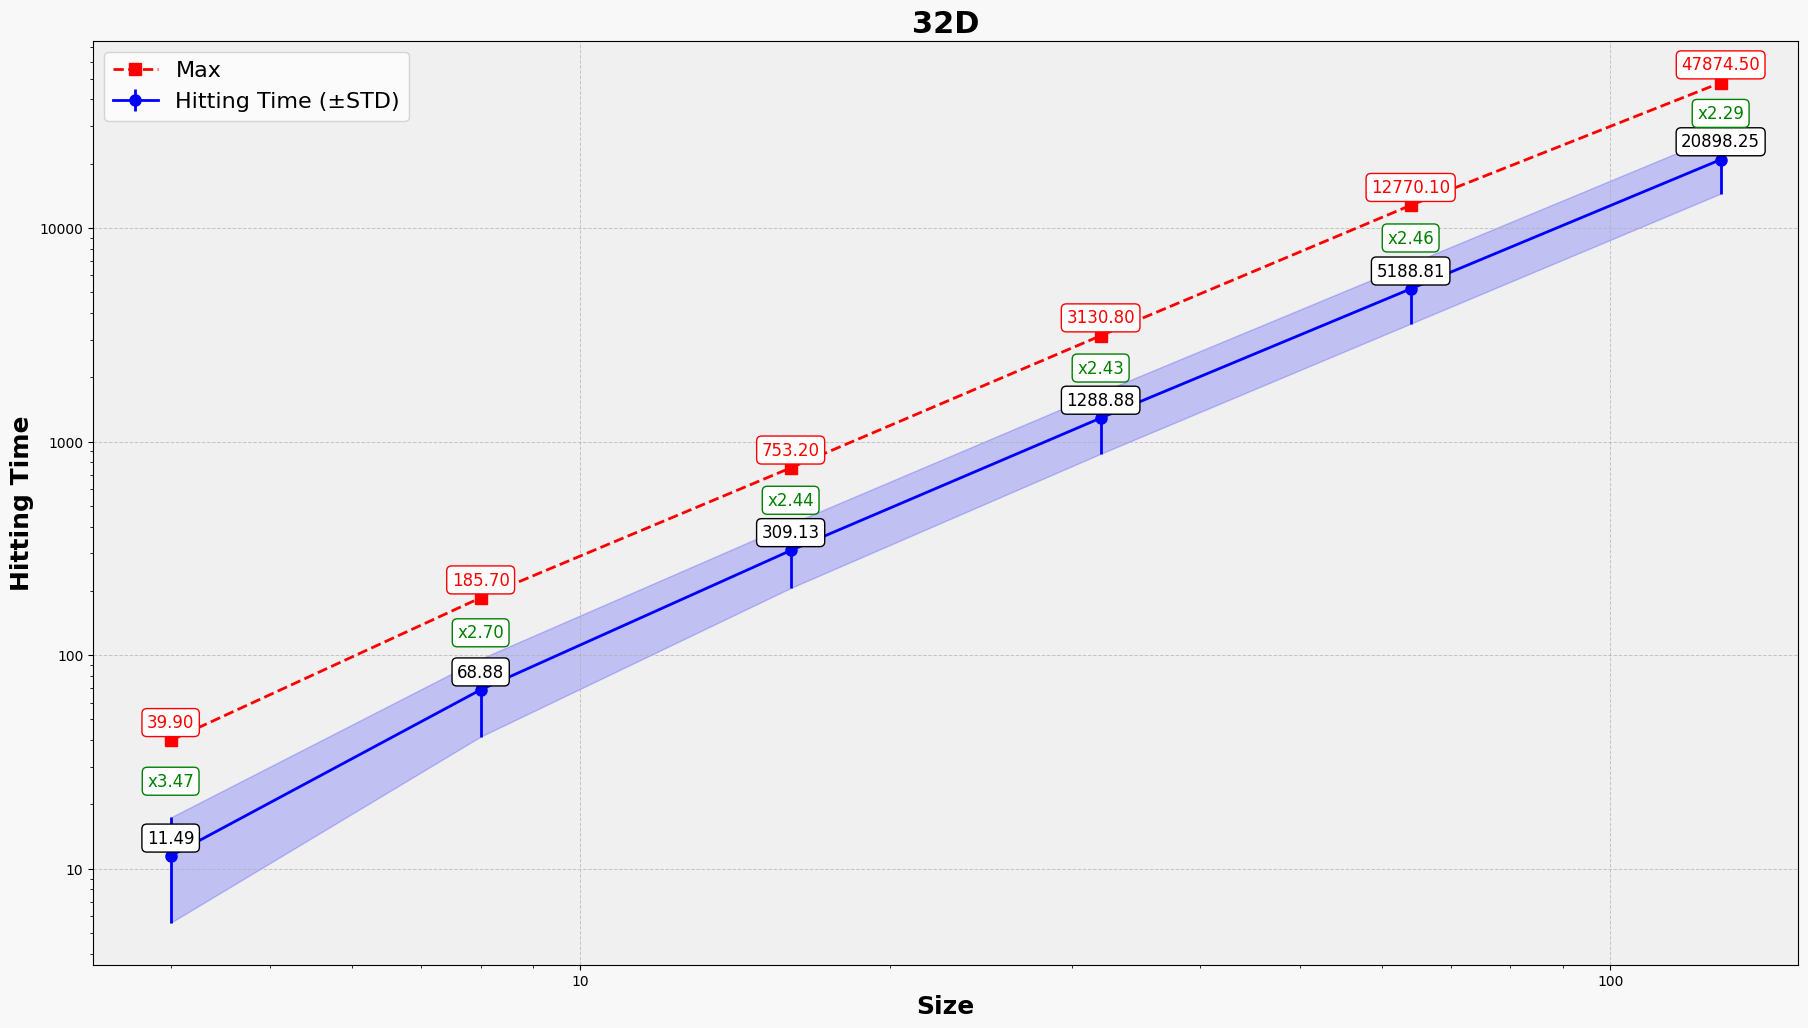

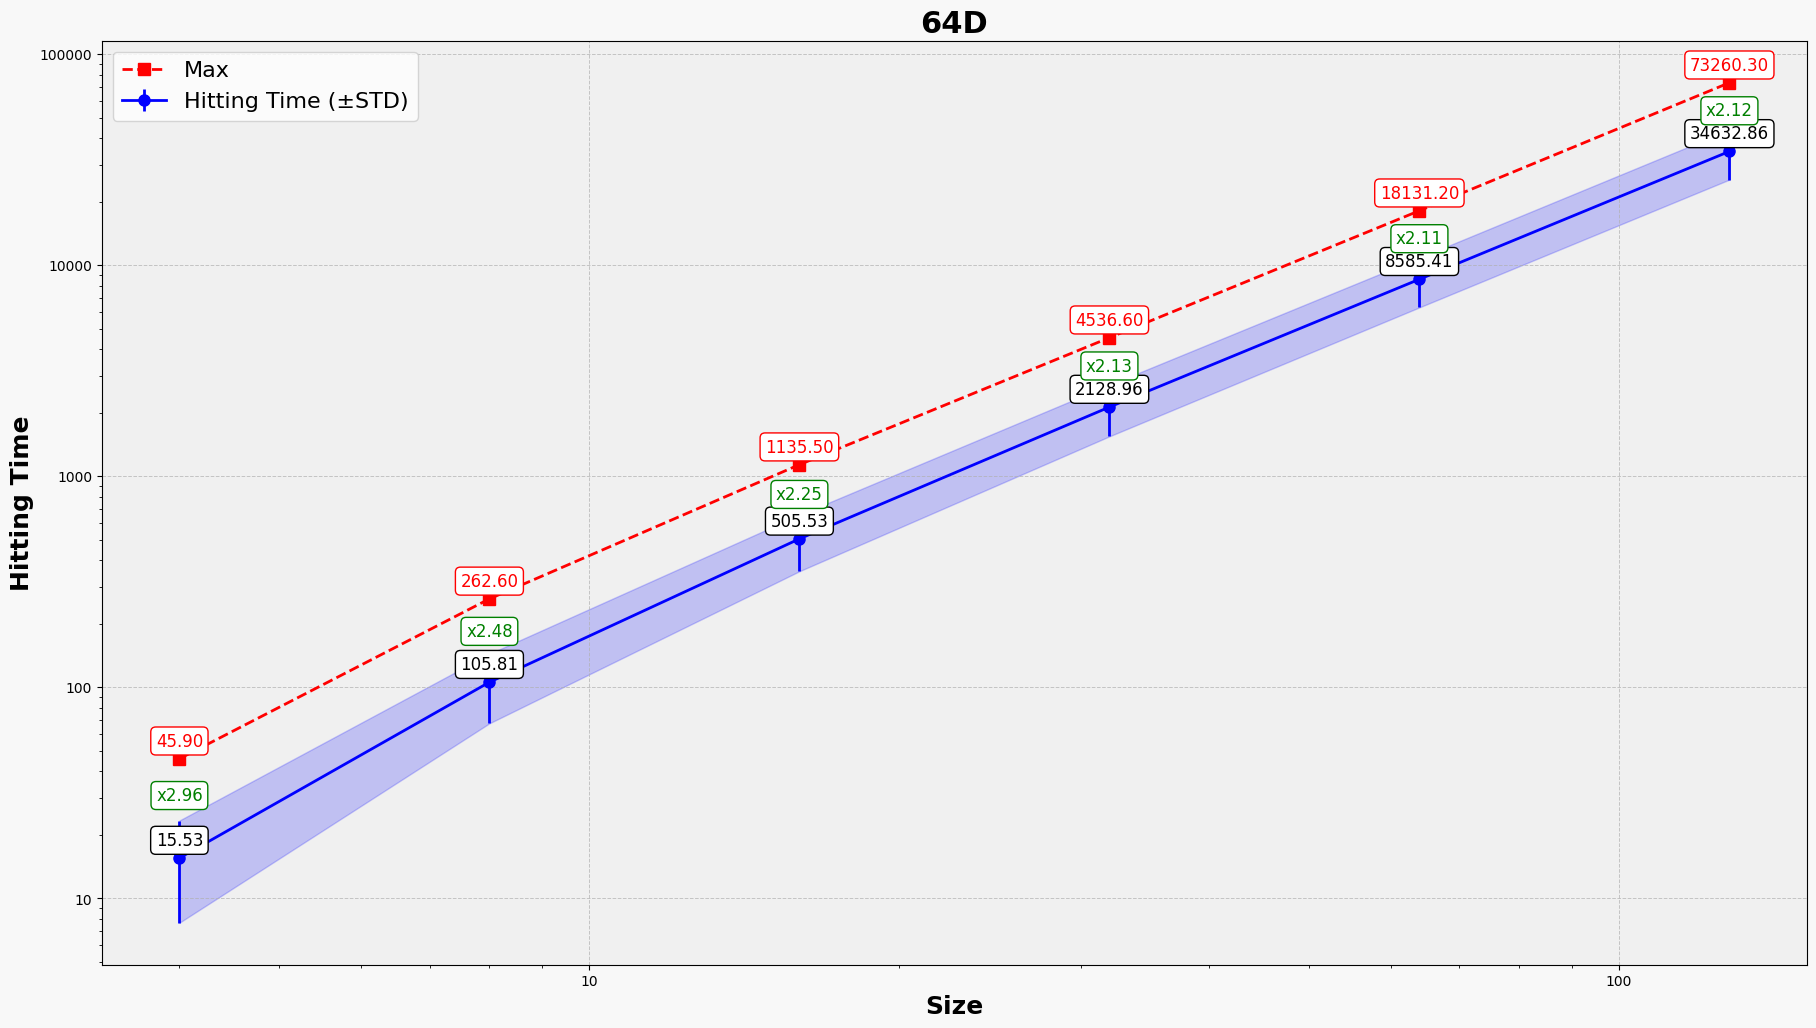

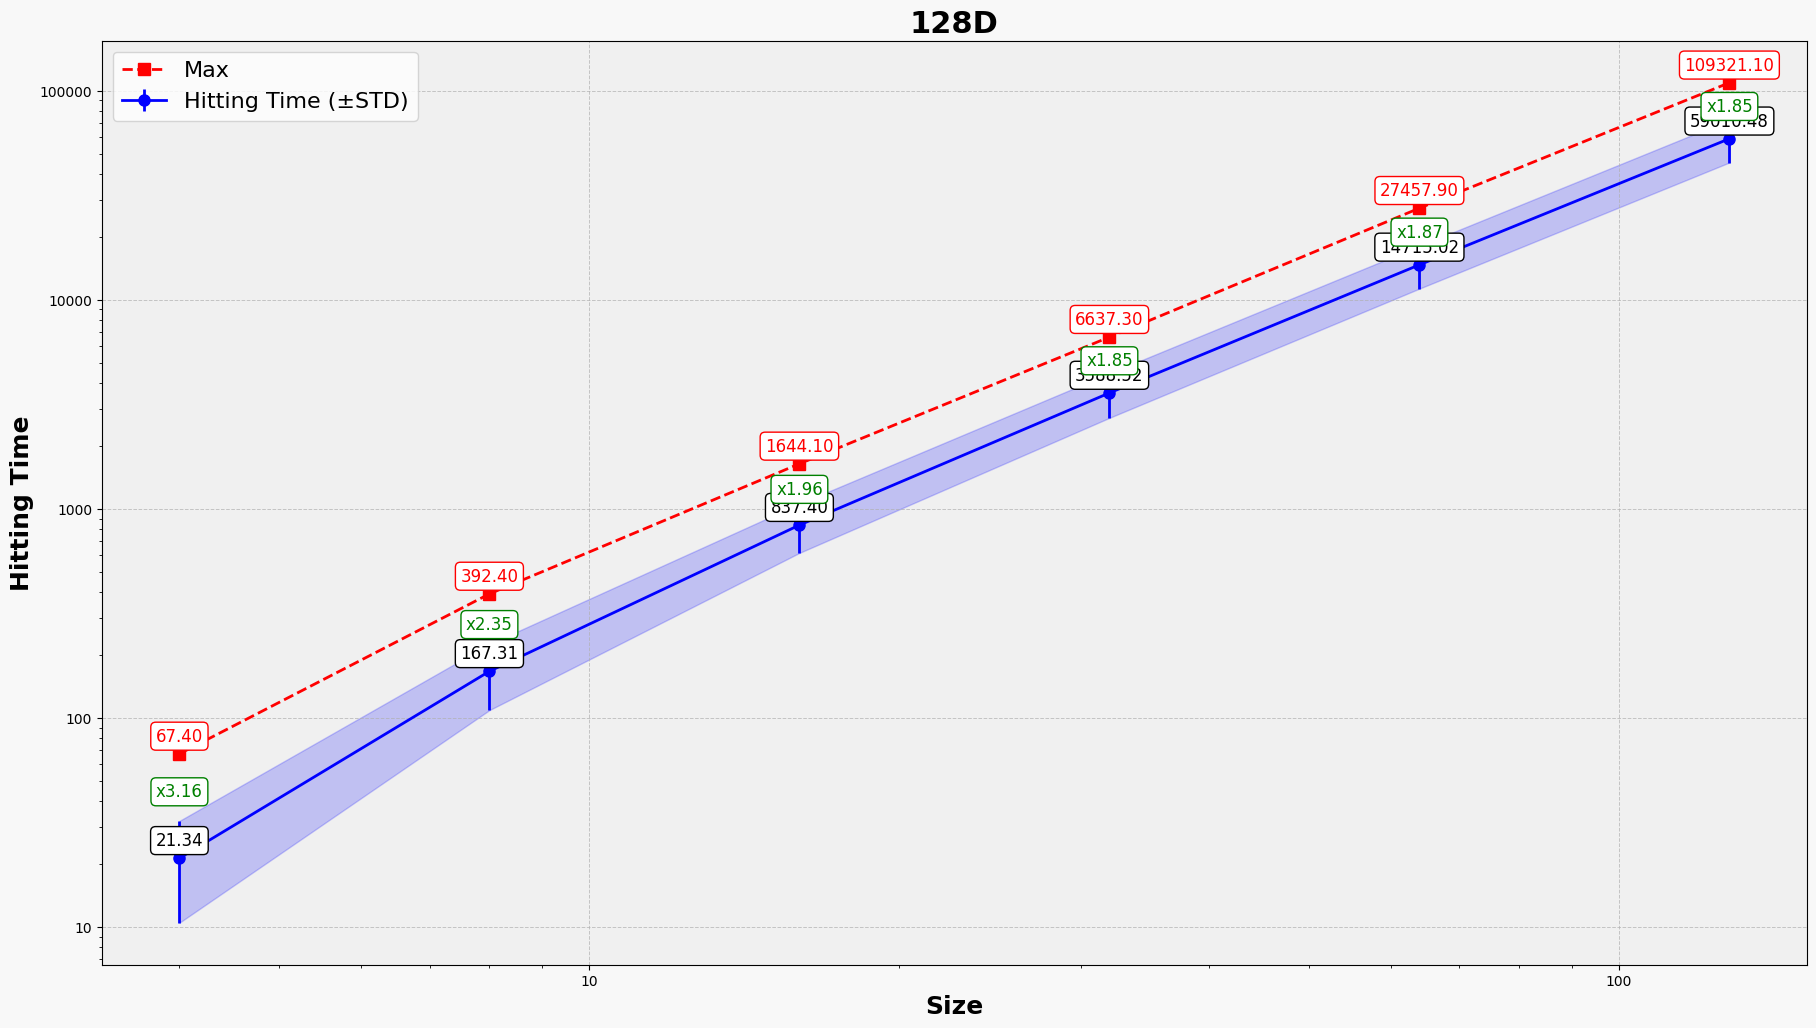

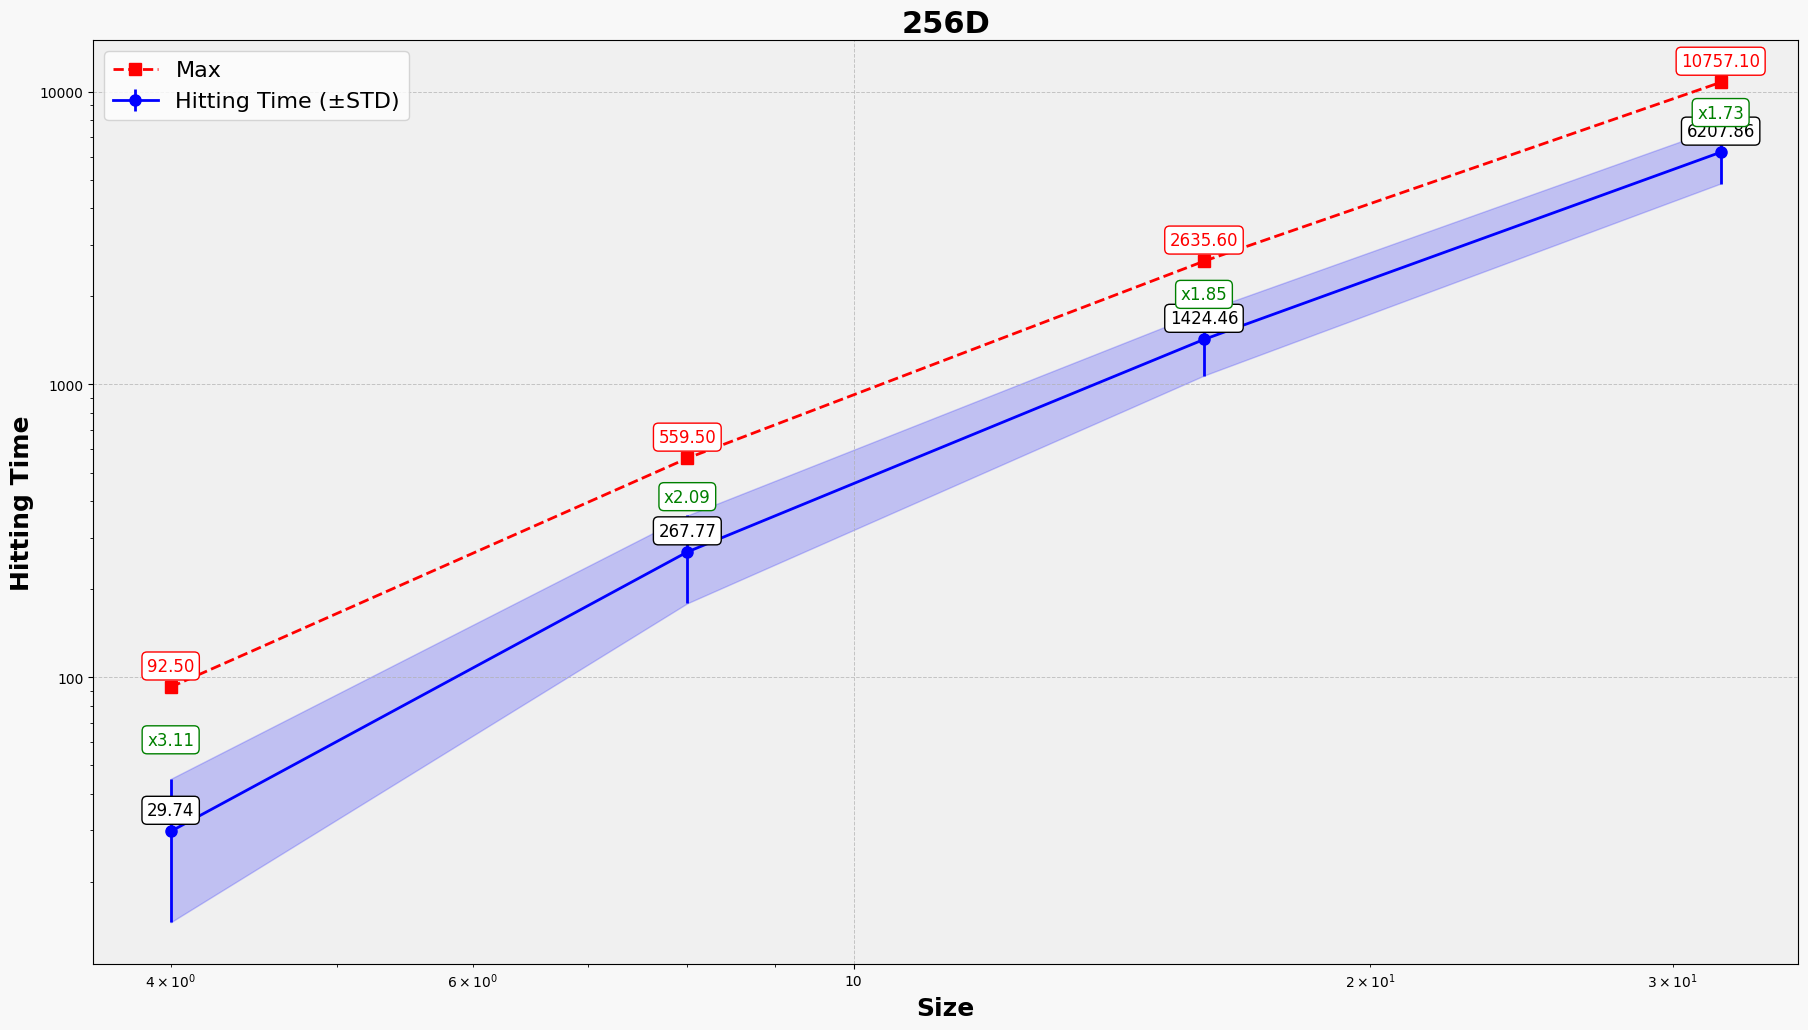

In [16]:
for dimension in [1, 2, 3, 4, 5, 6, 8, 12, 16, 32, 64, 128, 256]:
    plot_hitting_time(get_data(dimension, "../data/symmetry_walks.csv"))